In [1]:
"""
Acoustic Full Waveform Inversion using Salvus
==============================================
2-D acoustic FWI on a unit square domain [0,1]^2.

Workflow:
  1. Build homogeneous starting mesh and layered true mesh.
  2. Define source-receiver geometry and simulation configuration.
  3. Run forward simulation on the true model to generate observed data.
  4. Configure L2 misfit and inversion problem.
  5. Iterate the inversion loop.
"""

# ============================================================
# Imports
# ============================================================
import sys
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import salvus
import salvus.namespace as sn
import salvus.mesh.layered_meshing as lm

path_to_add = str(Path.cwd() / "tomography")
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

import my_code.utilities
importlib.reload(my_code.utilities)
from my_code.utilities import *


# ============================================================
# Configuration
# ============================================================
tx = 8

SITE_NAME = "isambard_oliver"
RANKS     = 8

f_c  = 2e4
VP   = 5000.0
RHO  = 2600.0

x0, x1 = 0.0, 1.0
y0, y1 = 0.0, 1.0

PROJECT_DIR = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project'
DATA_DIR    = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/data'
IMAGE_DIR   = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/image'

for d in [PROJECT_DIR, DATA_DIR, IMAGE_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)


# ============================================================
# Project
# ============================================================

PROJECT_NAME = 'acoustic_forward_5paris_' + str(tx) + 'tx_salvus'
domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR, PROJECT_NAME), domain=domain, load_if_exists=True
)


# ============================================================
# Mesh construction
# ============================================================

reference_frequency     = f_c * 2
elements_per_wavelength = 3
model_order             = 4
number_of_wavelengths   = 2
free_surfaces           = ['y0', 'y1']

ab_params = salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
    free_surface=free_surfaces,
    number_of_wavelengths=number_of_wavelengths,
    reference_velocity=VP,
    reference_frequency=reference_frequency,
)

mesh_res = sn.MeshResolution(
    reference_frequency=reference_frequency,
    elements_per_wavelength=elements_per_wavelength,
    model_order=model_order,
)

# Homogeneous starting model
m_homo    = sn.material.from_params(rho=RHO, vp=VP)
mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_homo, ab=ab_params),
    mesh_resolution=mesh_res,
)

# True model: layer with VP *= 1.5 between y = 0.4 and y = 0.6
mesh_true   = mesh_homo.copy()
centroids   = mesh_true.get_element_centroid()
defect_mask = (centroids[:, 1] >= 0.4) & (centroids[:, 1] <= 0.6)
mesh_true.elemental_fields["VP"][defect_mask] = 1.5 * VP

# Region of interest for inversion
roi      = [(0.0, 1.0), (0.4, 0.6)]
mesh_roi = generate_mesh_roi(mesh_homo, roi)


# # ============================================================
# # Source-receiver geometry
# # ============================================================

# amplitude_ratio = 1e3

# s_loc = [(x, 0.3) for x in np.linspace(0.2, 0.8, tx)]
# r_loc = [(x, 0.7) for x in np.linspace(0.2, 0.8, tx)]

# sources = [
#     sn.simple_config.source.cartesian.ScalarPoint2D(x=s[0], y=s[1], f=amplitude_ratio)
#     for s in s_loc
# ]

# receivers = [
#     sn.simple_config.receiver.cartesian.Point2D(
#         x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
#     )
#     for j, r in enumerate(r_loc)
# ]

# event_ls = [
#     sn.Event(event_name=f"event_{i+1}", sources=sources[i], receivers=receivers)
#     for i in range(len(sources))
# ]

# p.add_to_project(event_ls)


# # ============================================================
# # Simulation configuration
# # ============================================================

# end_time               = 2e-4
# start_time             = 0.0
# sampling_rate_in_hertz = f_c * 200
# time_shift_in_seconds  = 1.0 / f_c

# wavelet = sn.simple_config.stf.Ricker(
#     center_frequency=f_c,
#     time_shift_in_seconds=time_shift_in_seconds,
# )

# waveform_config = sn.WaveformSimulationConfiguration(
#     start_time_in_seconds=start_time,
#     end_time_in_seconds=end_time,
#     time_step_in_seconds=1.0 / sampling_rate_in_hertz,
# )

# event_config = sn.EventConfiguration(
#     wavelet=wavelet,
#     waveform_simulation_configuration=waveform_config,
# )

# homo_model = 'forward_simulation_homogeneous_model'
# true_model = 'forward_simulation_layered_model'

# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         unstructured_mesh=mesh_homo,
#         name=homo_model,
#         event_configuration=event_config,
#     ),
#     overwrite=True,
# )
# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         unstructured_mesh=mesh_true,
#         name=true_model,
#         event_configuration=event_config,
#     ),
#     overwrite=True,
# )


# # ============================================================
# # Forward simulation — generate observed data from true model
# # ============================================================

# t0 = datetime.now()

# forward_simulation(
#     p,
#     simulation_name=true_model,
#     events=event_ls,
#     fields=None,
#     sampling_interval_in_time_steps=10,
#     RANKS=RANKS,
# )

# print(f"Forward simulation completed in {datetime.now() - t0}")


# # ============================================================
# # Misfit configuration
# # ============================================================

# misfit_name = 'L2_misfit'

# p += sn.MisfitConfiguration(
#     name=misfit_name,
#     observed_data=true_model,
#     misfit_function="L2",
#     receiver_field="phi",
# )





# # ============================================================
# # Inverse problem configuration
# # ============================================================

# inverse_config_name = 'inversion_L2'

# invconfig = sn.InverseProblemConfiguration(
#     name=inverse_config_name,
#     prior_model=homo_model,
#     events=[e.event_name for e in event_ls],
#     misfit_configuration=misfit_name,
#     mapping=sn.Mapping(
#         scaling="absolute",
#         inversion_parameters=["VP"],
#         region_of_interest=mesh_roi,
#     ),
#     method=sn.TrustRegion(initial_trust_region_linf=1.0),
#     wavefield_compression=sn.WavefieldCompression(
#         forward_wavefield_sampling_interval=10
#     ),
#     job_submission=sn.SiteConfig(site_name=SITE_NAME, ranks_per_job=RANKS),
# )

# add_inversion(p, invconfig)

# p.inversions.set_job_submission_configuration(
#     inverse_config_name, sn.SiteConfig(site_name=SITE_NAME, ranks_per_job=RANKS)
# )


# # ============================================================
# # Inversion loop
# # ============================================================

# max_iterations           = 10
# timeout_in_seconds       = 360
# ping_interval_in_seconds = 50
# delete_disposable_files  = "all"

# for i in range(max_iterations):
#     p.inversions.iterate(
#         inverse_problem_configuration=inverse_config_name,
#         timeout_in_seconds=timeout_in_seconds,
#         ping_interval_in_seconds=ping_interval_in_seconds,
#         delete_disposable_files=delete_disposable_files,
#     )


--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.43 seconds]


Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-23 11:07:20,031] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_5paris_8tx_salvus.


In [4]:
tx = 1
PROJECT_NAME = 'acoustic_forward_5paris_' + str(tx) + 'tx_salvus'
domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR, PROJECT_NAME), domain=domain, load_if_exists=True
)


p.viz.nb.simulation_setup(
    simulation_configuration='forward_simulation_layered_model', events=p.events.list()
    )

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-22 22:59:12,795] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_5paris_1tx_salvus.


In [2]:
tx = 4
PROJECT_NAME = 'acoustic_forward_5paris_' + str(tx) + 'tx_salvus'


# salvus project 
p_salvus = sn.Project.from_domain(
    path=Path(PROJECT_DIR, PROJECT_NAME), domain=domain, load_if_exists=True
)
p_salvus.inversions.get_model("inversion_L2", 9)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-23 11:07:35,482] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_5paris_4tx_salvus.


In [3]:
def ellipse_mask(x, y, f1, f2, a):
    """
    Returns a boolean mask for points (x, y) inside an ellipse.
    
    f1, f2 : (x, y) tuples — the two focal points
    a      : semi-major axis length (half the sum of distances, i.e. 2a is total)
    """
    d1 = np.sqrt((x - f1[0])**2 + (y - f1[1])**2)
    d2 = np.sqrt((x - f2[0])**2 + (y - f2[1])**2)
    return (d1 + d2) <= 2 * a

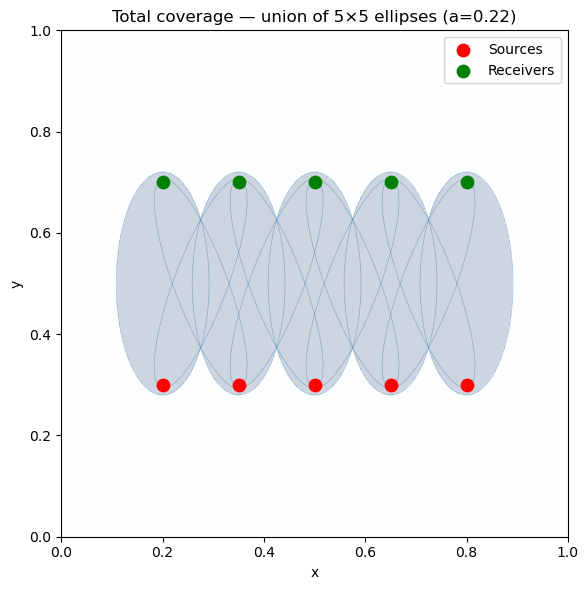

In [22]:
import matplotlib.pyplot as plt

tx = 5
s_loc = [(x, 0.3) for x in np.linspace(0.2, 0.8, tx)]
r_loc = [(x, 0.7) for x in np.linspace(0.2, 0.8, tx)]

a = 0.22

x_vals = np.linspace(0.0, 1.0, 400)
y_vals = np.linspace(0.0, 1.0, 400)
X, Y = np.meshgrid(x_vals, y_vals)

# Union of all 25 ellipses
coverage = np.zeros(X.shape, dtype=bool)
for s in s_loc:
    for r in r_loc:
        coverage |= ellipse_mask(X, Y, s, r, a)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(coverage, extent=[0, 1, 0, 1], origin='lower', cmap='Blues', alpha=0.2)

for s in s_loc:
    for r in r_loc:
        d1 = np.sqrt((X - s[0])**2 + (Y - s[1])**2)
        d2 = np.sqrt((X - r[0])**2 + (Y - r[1])**2)
        ax.contour(X, Y, d1 + d2, levels=[2 * a], colors='steelblue', linewidths=0.5, alpha=0.5)

ax.scatter([s[0] for s in s_loc], [s[1] for s in s_loc],
           color='red',   s=80, zorder=5, label='Sources')
ax.scatter([r[0] for r in r_loc], [r[1] for r in r_loc],
           color='green', s=80, zorder=5, label='Receivers')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Total coverage — union of {tx}×{tx} ellipses (a={a})')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [6]:
reconstruction = p_salvus.inversions.get_model("inversion_L2", 9)

In [7]:
reconstruction.get_element_centroid() # shape = (num_elements, 2)


array([[-0.27083333,  0.02083333],
       [-0.22916667,  0.02083333],
       [-0.1875    ,  0.02083333],
       ...,
       [ 1.1875    ,  0.97916667],
       [ 1.22916667,  0.97916667],
       [ 1.27083333,  0.97916667]])

In [8]:
vp_field = reconstruction.element_nodal_fields['VP'] # shape = (num_elements, num_nodes_per_element)
centroid = reconstruction.get_element_centroid() # shape = (num_elements, 2)





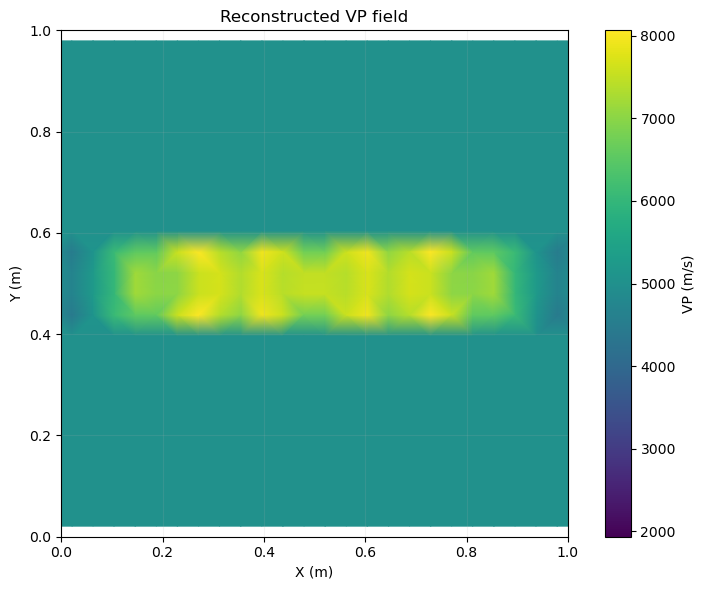

In [9]:
import matplotlib.pyplot as plt

vp_field = reconstruction.element_nodal_fields['VP']*VP + VP  # (num_elements, num_nodes)
centroid  = reconstruction.get_element_centroid()      # (num_elements, 2)

cx, cy    = centroid[:, 0], centroid[:, 1]
vp_elem   = vp_field.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
tp = ax.tripcolor(cx, cy, vp_elem, cmap='viridis', shading='gouraud', vmin=2*VP - vp_elem.max() , vmax=vp_elem.max())
plt.colorbar(tp, ax=ax, label='VP (m/s)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Reconstructed VP field', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

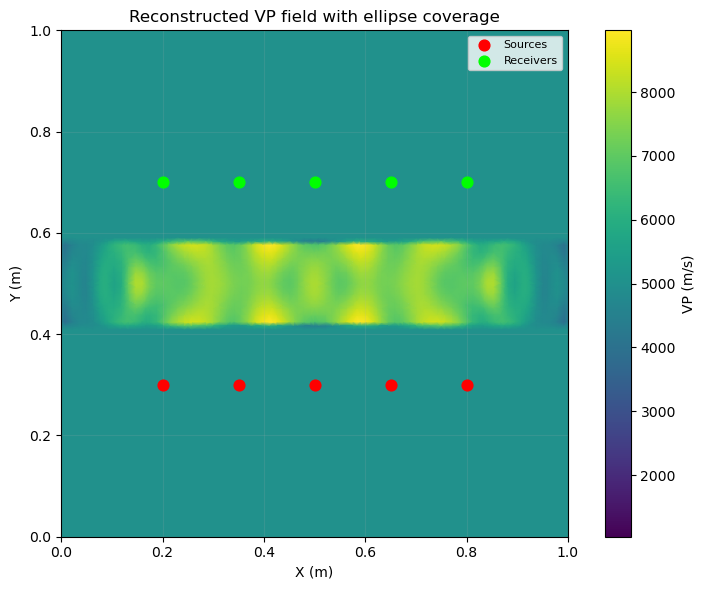

In [12]:
import matplotlib.pyplot as plt
import numpy as np

vp_field = reconstruction.element_nodal_fields['VP'] * VP + VP  # (925, 25)
x, y     = reconstruction.points[:, 0], reconstruction.points[:, 1]  # (14841,)
conn     = reconstruction.connectivity  # (925, 25) — global node indices

# Scatter element-local nodal VP to global nodes (average shared nodes)
vp_nodes = np.zeros(len(x))
count    = np.zeros(len(x))
np.add.at(vp_nodes, conn, vp_field)
np.add.at(count,    conn, 1)
vp_nodes /= count

# Ellipse parameters
tx_e  = 5
s_loc = [(sx, 0.3) for sx in np.linspace(0.2, 0.8, tx_e)]
r_loc = [(rx, 0.7) for rx in np.linspace(0.2, 0.8, tx_e)]
a     = 0.20

xg = np.linspace(0.0, 1.0, 400)
yg = np.linspace(0.0, 1.0, 400)
X, Y = np.meshgrid(xg, yg)

# Filter to physical domain
dom = (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
tp = ax.tripcolor(x[dom], y[dom], vp_nodes[dom], cmap='viridis', shading='gouraud',
                  vmin=2 * VP - vp_nodes[dom].max(), vmax=vp_nodes[dom].max())
plt.colorbar(tp, ax=ax, label='VP (m/s)')

# Ellipse outlines
for s in s_loc:
    for r in r_loc:
        d1 = np.sqrt((X - s[0])**2 + (Y - s[1])**2)
        d2 = np.sqrt((X - r[0])**2 + (Y - r[1])**2)
        ax.contour(X, Y, d1 + d2, levels=[2 * a],
                   colors='white', linewidths=0.5, alpha=0.5)

ax.scatter([s[0] for s in s_loc], [s[1] for s in s_loc],
           color='red',  s=60, zorder=5, label='Sources')
ax.scatter([r[0] for r in r_loc], [r[1] for r in r_loc],
           color='lime', s=60, zorder=5, label='Receivers')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Reconstructed VP field with ellipse coverage', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.grid(alpha=0.15)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

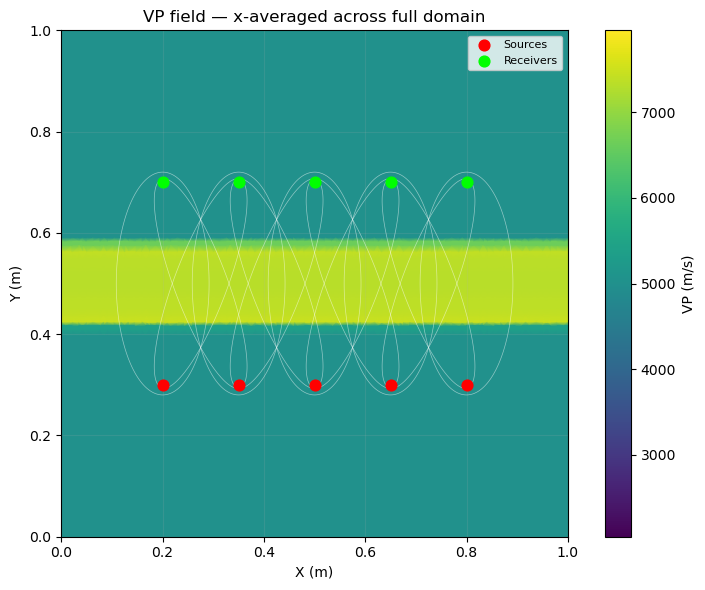

In [17]:
def ellipse_coverage_mask(x, y, s_loc, r_loc, a):
    """Boolean node mask: True where any source-receiver ellipse covers the node."""
    mask = np.zeros(len(x), dtype=bool)
    for s in s_loc:
        for r in r_loc:
            d1 = np.sqrt((x - s[0])**2 + (y - s[1])**2)
            d2 = np.sqrt((x - r[0])**2 + (y - r[1])**2)
            mask |= (d1 + d2) <= 2 * a
    return mask


def xaverage_vp(vp_nodes, x, y, dom, in_ellipse, n_bins=60):
    """Replace each domain node's VP with the y-bin mean over ellipse nodes."""
    y_edges = np.linspace(0, 1, n_bins + 1)
    vp_avg  = vp_nodes.copy()
    for i in range(n_bins):
        bin_mask    = dom & (y >= y_edges[i]) & (y < y_edges[i + 1])
        ellipse_bin = bin_mask & in_ellipse
        if bin_mask.any():
            mean_val = vp_nodes[ellipse_bin].mean() if ellipse_bin.any() else vp_nodes[bin_mask].mean()
            vp_avg[bin_mask] = mean_val
    return vp_avg


# --- usage ---
tx_e  = 5
s_loc = [(sx, 0.3) for sx in np.linspace(0.2, 0.8, tx_e)]
r_loc = [(rx, 0.7) for rx in np.linspace(0.2, 0.8, tx_e)]
a     = 0.20

in_ellipse = ellipse_coverage_mask(x, y, s_loc, r_loc, a)
vp_avg     = xaverage_vp(vp_nodes, x, y, dom, in_ellipse)


a     = 0.22
in_ellipse = ellipse_coverage_mask(x, y, s_loc, r_loc, a)
vp_avg_ellipse    = xaverage_vp(vp_nodes, x, y, dom, in_ellipse)



# Plot
xg, yg = np.linspace(0.0, 1.0, 400), np.linspace(0.0, 1.0, 400)
X, Y   = np.meshgrid(xg, yg)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
tp = ax.tripcolor(x[dom], y[dom], vp_avg_ellipse[dom], cmap='viridis', shading='gouraud',
                  vmin=2 * VP - vp_avg[dom].max(), vmax=vp_avg[dom].max())
plt.colorbar(tp, ax=ax, label='VP (m/s)')

for s in s_loc:
    for r in r_loc:
        d1 = np.sqrt((X - s[0])**2 + (Y - s[1])**2)
        d2 = np.sqrt((X - r[0])**2 + (Y - r[1])**2)
        ax.contour(X, Y, d1 + d2, levels=[2 * a], colors='white', linewidths=0.5, alpha=0.5)

ax.scatter([s[0] for s in s_loc], [s[1] for s in s_loc], color='red',  s=60, zorder=5, label='Sources')
ax.scatter([r[0] for r in r_loc], [r[1] for r in r_loc], color='lime', s=60, zorder=5, label='Receivers')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('VP field — x-averaged across full domain', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.grid(alpha=0.15); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:


# Map true element_nodal_fields to global nodes
true_mesh = p.simulations.get_mesh('forward_simulation_layered_model')
vp_field_true = true_mesh.element_nodal_fields['VP']

conn          = reconstruction.connectivity
vp_true_nodes = np.zeros(len(x))
count_t       = np.zeros(len(x))
np.add.at(vp_true_nodes, conn, vp_field_true)
np.add.at(count_t,       conn, 1)
vp_true_nodes /= count_t

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

rmse_raw = rmse(vp_nodes[dom], vp_true_nodes[dom])
rmse_average = rmse(vp_avg[dom], vp_true_nodes[dom])
rmse_ellipse  = rmse(vp_avg_ellipse[dom], vp_true_nodes[dom])


print(f"RMSE (raw reconstruction) : {rmse_raw:.2f} m/s")
print(f"RMSE (x-averaged) : {rmse_average:.2f} m/s")
print(f"RMSE (within ellipse coverage): {rmse_ellipse:.2f} m/s")

RMSE (raw reconstruction) : 516.95 m/s
RMSE (x-averaged) : 285.39 m/s
RMSE (within ellipse coverage): 145.96 m/s
